Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

[2] A. Béres, Denoising Diffusion Implicit Models, disponível no site do Keras [(link)](https://keras.io/examples/generative/ddim/).

# Importações

In [1]:
! pip install torchinfo

In [7]:
import os                                               # funções para manipular o sistema de arquivos (criar pastas, listar arquivos etc.)
import math                                             # funções matemáticas adicionais (ex.: pi, seno, cosseno)
import numpy as np                                      # operações numéricas vetorizadas e matrizes (álgebra linear)
import matplotlib.pyplot as plt                         # biblioteca padrão para visualização e plots
import torch                                            # biblioteca central do PyTorch: tensores + autograd
from torch import nn                                    # módulos de redes neurais (Layers, Sequential, etc.)
from torchvision import transforms                      # pré-processamentos para imagens (resize, to-tensor, normalização)
from torch.nn.parameter import UninitializedParameter   # utilitário PyTorch: parâmetro não inicializado (camadas lazy)
from torchvision.datasets import MNIST                   # dataset MNIST (dígitos manuscritos)
from torch.utils.data import DataLoader, ConcatDataset  # DataLoader + concatenação de múltiplos datasets
import copy                                             # deep copy (usado para clonar pesos — ex.: EMA)
from tqdm.auto import tqdm                              # barra de progresso automática (suporta notebook/terminal)
import imageio                                          # leitura/escrita de imagens e vídeos (GIF/MP4)
from IPython.display import Image, display    
          # utilidades p/ exibir imagens no notebook

In [8]:
plt.style.use("seaborn-v0_8-colorblind")                # estilo de plot colorblind-safe, mais limpo
os.makedirs("./output", exist_ok=True)                  # cria diretório ./output se não existir (salvamento de amostras)

# Hiperparâmetros

In [ ]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # seleciona GPU via torch.accelerator (ou CPU caso não exista GPU)
IMAGE_SIZE = 32                 # tamanho das imagens (32x32)
NUM_CHANNELS = 1                # número de canais da imagem
BATCH_SIZE = 64                 # tamanho do mini-lote
NOISE_EMBEDDING_SIZE = 32       # dimensão do embedding senoidal do tempo/ruído
PLOT_DIFFUSION_STEPS = 20       # passos de difusão para visualização
EMA = 0.999                     # taxa para Exponential Moving Average dos pesos
LEARNING_RATE = 1e-3            # taxa de aprendizado do otimizador
WEIGHT_DECAY = 1e-4             # regularização L2
EPOCHS = 10                     # número total de épocas de treinamento

# Carregar e pré-processar o conjunto de dados [Oxford 102 Flower](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/)

In [71]:
def carregar_dados_mnist(transformacao_imagem, tamanho_lote):

    # Carrega conjunto de treinamento (baixado automaticamente se não existir)
    train_data = MNIST(
        root="dados",
        train=True,
        transform=transformacao_imagem,
        download=True,
    )

    # Carrega conjunto de teste (baixado automaticamente se não existir)
    test_data = MNIST(
        root="dados",
        train=False,
        transform=transformacao_imagem,
        download=True,
    )

    return train_data, test_data, len(train_data)

In [74]:
# Transforms (resize + ToTensor)
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),                                                    # redimensiona p/ 64x64
    transforms.ToTensor(),                                                                          # converte p/ tensor com valores no intervalo [0,1]
])

train_ds, test_ds, _ = carregar_dados_mnist(transformacao_imagem=transform, tamanho_lote=BATCH_SIZE)


print(f'train_ds:   {type(train_ds)}   |   {len(train_ds)} exemplos.')
print(f'test_ds:    {type(test_ds)}   |   {len(test_ds)} exemplos.')

# Concatena os conjuntos
full_ds = ConcatDataset([train_ds, test_ds])                                                # conjunto de dados completo
print(f'full_ds:    {type(full_ds)}       |   {len(full_ds)} exemplos.')

#  Repete dataset DATASET_REPETITIONS vezes
# rep_ds = ConcatDataset([full_ds for _ in range(DATASET_REPETITIONS)])
# print(f'rep_ds:     {type(rep_ds)}       |   {len(rep_ds)} exemplos.')

# DataLoader
train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=4
)
print(f'train_dl:   {type(train_dl)}')

train_ds:   <class 'torchvision.datasets.mnist.MNIST'>   |   60000 exemplos.
test_ds:    <class 'torchvision.datasets.mnist.MNIST'>   |   10000 exemplos.
full_ds:    <class 'torch.utils.data.dataset.ConcatDataset'>       |   70000 exemplos.
train_dl:   <class 'torch.utils.data.dataloader.DataLoader'>


## Mostra exemplos do conjunto de dados

In [20]:
def sample_batch(dataloader):
    """Retorna um lote de imagens do DataLoader."""
    batch = next(iter(dataloader))          # seleciona o primeiro lote do loader
    if isinstance(batch, (tuple, list)):    # caso o dataloader retorne uma tupla/lista, significa que ele está no formato (x = imagens, y = rótulos)
        batch = batch[0]                    # descarta os rótulos e seleciona apenas as imagens
    return batch                            # retorna tensor PyTorch no formato (B, C, H, W)

In [21]:
def plot_images(
    images,
    n=10,
    size=(20, 3),
    cmap="gray_r",
    as_type="float32",
    save_to=None,
    show=True,
    ylabel=None
):
    """Mostra n imagens de um tensor PyTorch ou array NumPy."""
    if isinstance(images, torch.Tensor):                       # se for tensor PyTorch
        images = images.detach().cpu().permute(0, 2, 3, 1)     # (B,C,H,W)->(B,H,W,C)
        images = images.numpy()                                 # para NumPy

    plt.figure(figsize=size)                                    # cria figura
    for i in range(n):                                          # percorre as n primeiras imagens
        ax = plt.subplot(1, n, i + 1)                           # subplot horizontal
        ax.imshow(images[i].astype(as_type), cmap=cmap)         # renderiza imagem

        if i == 0 and ylabel is not None:                       # rótulo apenas no 1º subplot
            ax.set_ylabel(
                ylabel,
                fontsize=16,
                color="red",
                fontweight="bold"
            )
            ax.set_xticks([]); ax.set_yticks([])                # remove ticks
            for sp in ax.spines.values(): sp.set_visible(False) # esconde moldura
        else:
            ax.axis("off")                                      # remove tudo nos demais

    if save_to:
        plt.savefig(save_to, bbox_inches="tight", pad_inches=0)  # margem mínima
    if show:
        plt.show()

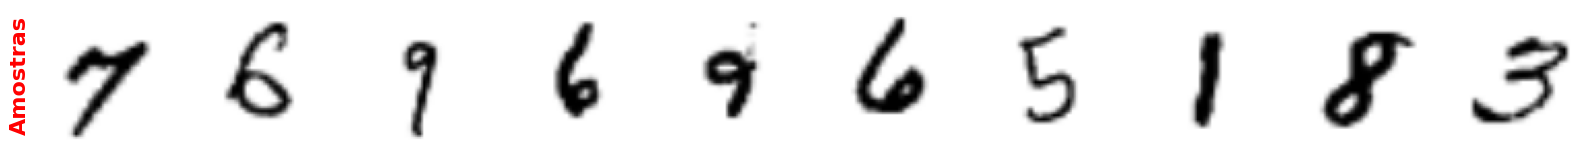

train_sample:   <class 'torch.Tensor'>   |   torch.Size([64, 1, 64, 64])   |   min=0.0   |   max=1.0


In [22]:
train_sample = sample_batch(train_dl)           # seleciona 1 batch do DataLoader
plot_images(train_sample, ylabel="Amostras")    # plota imagens
print(f'train_sample:   {type(train_sample)}   |   {train_sample.shape}   |   min={train_sample.min()}   |   max={train_sample.max()}')

# Cronograma de difusão

- **Maneira como $\beta_t$ ou $\bar{\alpha}_t$ variam com $t$.**

## Cronograma 1: $\quad β_t \quad$ linear

- Artigo original:
    - $\beta_1=10^{-4}$
    - $\beta_T=2 \cdot 10^{-2}$

In [24]:
def linear_diffusion_schedule(diffusion_times: torch.Tensor, dim: int = 0):
    """Retorna (noise_rates, signal_rates) para um β_t linear."""
    min_rate = 1e-4                                              # β_1
    max_rate = 2e-2                                              # β_T
    betas = min_rate + diffusion_times * (max_rate - min_rate)   # β_t cresce linearmente em t/T ∈ [0,1]
    alphas = 1.0 - betas                                         # α_t = 1 − β_t
    alpha_bars = torch.cumprod(alphas, dim=dim)                  # ᾱ_t = ∏_{i≤t} α_i (cumulativo ao longo de 'dim')
    signal_rates = torch.sqrt(alpha_bars)                        # √ᾱ_t         (componente do “sinal” - imagem)
    noise_rates  = torch.sqrt(1.0 - alpha_bars)                  # √(1 − ᾱ_t)   (componente do “ruído”)
    return noise_rates, signal_rates                             # retorna tupla (ruído, sinal)

## Cronograma 2: $\displaystyle \quad \bar{\alpha}_t = cos^2 \left( \frac{t}{T} \cdot \frac{\pi}{2} \right)$


- Kernel de difusão:

$\displaystyle \mathbf z_t
= \underbrace{\sqrt{\bar{\alpha}_t}}_{\substack{\text{fator de escala}\\\text{do sinal}}}
\cdot
\underbrace{\mathbf x}_{\substack{\text{sinal}\\\text{(ex.: imagem)}}} + \underbrace{\sqrt{1-\bar{\alpha}_t}}_{\substack{\text{fator de escala}\\\text{do ruído}}}  
\cdot
\underbrace{\mathbf \epsilon}_{\text{ruído}} $

$\displaystyle \mathbf z_t  = cos \left( \frac{t}{T} \cdot \frac{\pi}{2} \right) \cdot \mathbf x + sin \left( \frac{t}{T} \cdot \frac{\pi}{2} \right) \cdot \mathbf \epsilon$

- Identidade trigonométrica:

$\displaystyle  cos^2 (x) + sin^2 (x) = 1$

In [25]:
def cosine_diffusion_schedule(diffusion_times: torch.Tensor):
    """Retorna (noise_rates, signal_rates) com ᾱ_t = cos²(π (t/T) / 2)."""

    # √ᾱ_t  = cos(π (t/T) / 2)
    signal_rates = torch.cos(diffusion_times * math.pi / 2)      # componente de sinal

    # √(1 − ᾱ_t) = sin(π (t/T) / 2)
    noise_rates  = torch.sin(diffusion_times * math.pi / 2)      # componente de ruído

    return noise_rates, signal_rates                             # retorna tupla (ruído, sinal)

## Cronograma 3: cosseno "deslocado"

 - Mantém ᾱ_t em [min_signal_rate², max_signal_rate²] para evitar extremos numéricos (0 e 1)

In [26]:
def offset_cosine_diffusion_schedule(diffusion_times: torch.Tensor):
    """Retorna (noise_rates, signal_rates) com cosseno deslocado para
    limitar ᾱ_t dentro de um intervalo seguro."""

    min_signal_rate = torch.tensor(0.02, dtype=diffusion_times.dtype, device=diffusion_times.device)  # evita ᾱ_t → 0
    max_signal_rate = torch.tensor(0.95, dtype=diffusion_times.dtype, device=diffusion_times.device)  # evita ᾱ_t → 1

    # ângulos associados aos limites de ᾱ_t
    start_angle = torch.acos(max_signal_rate)    # cos θ_0 = 0.95
    end_angle   = torch.acos(min_signal_rate)    # cos θ_T = 0.02

    # interpolação linear do ângulo conforme t
    diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

    # converte ângulo → (√ᾱ_t, √(1−ᾱ_t))
    signal_rates = torch.cos(diffusion_angles)   # √ᾱ_t
    noise_rates  = torch.sin(diffusion_angles)   # √(1−ᾱ_t)

    return noise_rates, signal_rates    # retorna tupla (ruído, sinal)

## Comparação dos 3 cronogramas

In [27]:
T = 1000                                                                                                        # número total de passos
diffusion_times = torch.arange(T, dtype=torch.float32)                                                          # vetor [0, 1, 2, ..., T-1]
diffusion_times = diffusion_times / T                                                                           # normaliza p/ t ∈ [0, 1)

# Calcula as curvas (ruído e sinal) para cada cronograma
linear_noise_rates,  linear_signal_rates  = linear_diffusion_schedule(diffusion_times)                          # cronograma linear
cosine_noise_rates,  cosine_signal_rates  = cosine_diffusion_schedule(diffusion_times)                          # cronograma cosseno
offset_noise_rates,  offset_signal_rates  = offset_cosine_diffusion_schedule(diffusion_times)                   # cronograma cosseno deslocado

# Imprime min/max das taxas de ruído
print('noise_rates:')
print(f'\tlinear: [{linear_noise_rates.min().item():.4f}, {linear_noise_rates.max().item():.4f}]')              # faixa de √(1-ᾱ_t)
print(f'\tcosseno: [{cosine_noise_rates.min().item():.4f}, {cosine_noise_rates.max().item():.4f}]')             # faixa de √(1-ᾱ_t)
print(f'\tcosseno deslocado: [{offset_noise_rates.min().item():.4f}, {offset_noise_rates.max().item():.4f}]')   # faixa de √(1-ᾱ_t)

# Imprime min/max das taxas de sinal
print('signal_rates:')
print(f'\tlinear: [{linear_signal_rates.min().item():.4f}, {linear_signal_rates.max().item():.4f}]')            # faixa de √ᾱ_t
print(f'\tcosseno: [{cosine_signal_rates.min().item():.4f}, {cosine_signal_rates.max().item():.4f}]')           # faixa de √ᾱ_t
print(f'\tcosseno deslocado: [{offset_signal_rates.min().item():.4f}, {offset_signal_rates.max().item():.4f}]') # faixa de √ᾱ_t

noise_rates:
	linear: [0.0100, 1.0000]
	cosseno: [0.0000, 1.0000]
	cosseno deslocado: [0.3122, 0.9998]
signal_rates:
	linear: [0.0064, 0.9999]
	cosseno: [0.0016, 1.0000]
	cosseno deslocado: [0.0212, 0.9500]


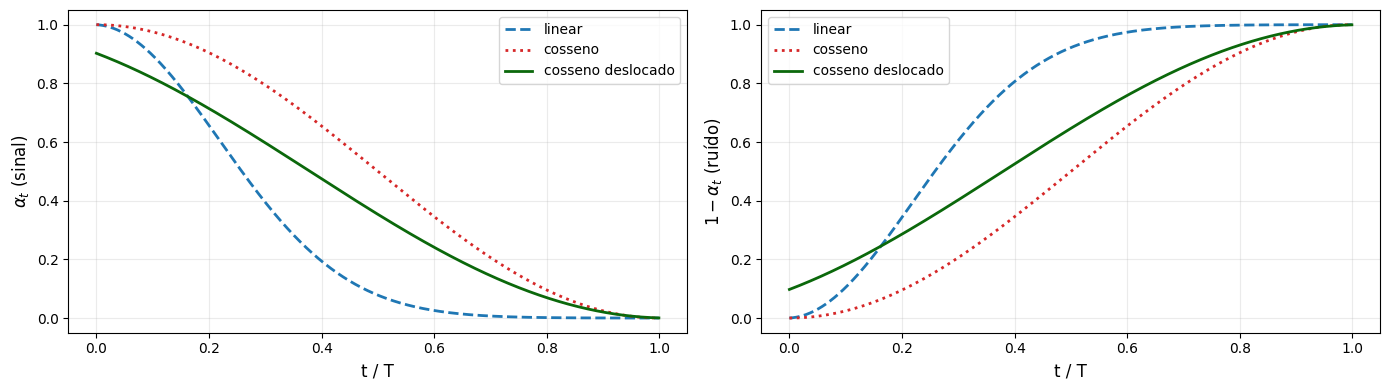

In [28]:
# -----------------------------------------------------------
# Estilos para as curvas
# -----------------------------------------------------------
styles = {
    "linear":         {"color": "#1f77b4", "linestyle": "--",  "linewidth": 2.0},  # azul tracejado
    "cosine":         {"color": "#d62728", "linestyle": ":",   "linewidth": 2.0},  # vermelho pontilhado
    "offset_cosine":  {"color": "#0b680b", "linestyle": "-",   "linewidth": 2.0},  # verde sólido
}

# Converte tensores para numpy (necessário para plt.plot)
dt_np = diffusion_times.cpu().numpy()                  # t ∈ [0,1]
lin_sig = (linear_signal_rates**2).cpu().numpy()       # ᾱ_t (linear)
cos_sig = (cosine_signal_rates**2).cpu().numpy()       # ᾱ_t (cosseno)
off_sig = (offset_signal_rates**2).cpu().numpy()       # ᾱ_t (cosseno deslocado)

lin_noise = (linear_noise_rates**2).cpu().numpy()      # 1−ᾱ_t (linear)
cos_noise = (cosine_noise_rates**2).cpu().numpy()      # 1−ᾱ_t (cosseno)
off_noise = (offset_noise_rates**2).cpu().numpy()      # 1−ᾱ_t (cosseno deslocado)

# -----------------------------------------------------------
# Plot
# -----------------------------------------------------------
plt.figure(figsize=(14, 4))                              # define tamanho da figura

# Plot ᾱ_t (≡ signal_rates²) para cada cronograma
plt.subplot(1,2,1)
plt.plot(dt_np, lin_sig, label="linear", **styles["linear"])
plt.plot(dt_np, cos_sig, label="cosseno", **styles["cosine"])
plt.plot(dt_np, off_sig, label="cosseno deslocado", **styles["offset_cosine"])

plt.xlabel("t / T", fontsize=12)                       # rótulo eixo x
plt.ylabel(r"$\alpha_t$ (sinal)", fontsize=12)                 # rótulo eixo y
plt.legend()                                           # legenda
plt.grid(alpha=0.25)                                   # grade leve
plt.tight_layout()                                     # layout automático

# Plot (1 − ᾱ_t) (≡ noise_rates²) para cada cronograma
plt.subplot(1,2,2)
plt.plot(dt_np, lin_noise, label="linear", **styles["linear"])
plt.plot(dt_np, cos_noise, label="cosseno", **styles["cosine"])
plt.plot(dt_np, off_noise, label="cosseno deslocado", **styles["offset_cosine"])

plt.xlabel("t / T", fontsize=12)
plt.ylabel(r"$1 - \alpha_t$ (ruído)", fontsize=12)
plt.legend()
plt.grid(alpha=0.25)                                   # grade leve
plt.tight_layout()

plt.show()

# Modelo de difusão

## Embedding senoidal

In [75]:
def sinusoidal_embedding(x: torch.Tensor):
    """
    Gera embedding senoidal do tempo (mesmo t para toda a imagem).

    Parâmetros
    ----------
    x : torch.Tensor
        Tensor com o tempo/variância por amostra (escalares)
        Shape esperado: (B, 1, 1, 1)

    Retorna
    -------
    embeddings : torch.Tensor
        Embedding senoidal
        Shape: (B, 1, 1, NOISE_EMBEDDING_SIZE)
    """

    # Gera frequências log-espaçadas e^{k·s} para o embedding senoidal com fator de escala
    # para as frequências s = ln(1000)/(L−1), k = 0,...,L−1
    # torch.linspace(start, end, L) produz L valores igualmente espaçados entre start e end:
    #     grid[k] = start + k * (end - start)/(L-1)
    # como start = ln(1)=0 e end = ln(1000), temos:
    #     grid[k] = 0 + k * (ln(1000) - 0)/(L-1) = k * ln(1000)/(L-1) = k·s
    # então torch.exp(grid) produz exatamente:
    #     frequencies = [e^(0·s), e^(1·s), ..., e^((L−1)·s)]

    # Calcula frequências
    start = math.log(1.0)                                       # ln(1) = 0 → início da escala log
    end   = math.log(1000.0)                                    # ln(1000) → fim da escala log
    L = NOISE_EMBEDDING_SIZE // 2                               # metade das dimensões para seno e metade para cosseno
    frequencies = torch.exp(torch.linspace(start, end, L, device=x.device, dtype=x.dtype))  # exp(linspace) = [e^{0·s}, e^{1·s}, ..., e^{(L−1)·s}], shape: (NOISE_EMBEDDING_SIZE/2,)

    # Calcula velocidades angulares
    angular_speeds = 2.0 * torch.pi * frequencies               # ω_k = 2πf_k = 2π · e^{k·s}, shape: (NOISE_EMBEDDING_SIZE // 2,)
    angular_speeds = angular_speeds.view(1, 1, 1, -1)           # reshape p/ broadcast: (NOISE_EMBEDDING_SIZE // 2,)-> (1,1,1,NOISE_EMBEDDING_SIZE//2) permite (B,1,1,1)*(1,1,1,L)->(B,1,1,L)

    # Calcula seno e cosseno: sin(ωx), cos(ωx)
    sin_embed = torch.sin(angular_speeds * x)                   # shape: (B,1,1,NOISE_EMBEDDING_SIZE/2)
    cos_embed = torch.cos(angular_speeds * x)                   # shape: (B,1,1,NOISE_EMBEDDING_SIZE/2)

    # Embeddings
    embeddings = torch.cat([sin_embed, cos_embed], dim=-1)      # concatena canais: (B,1,1,NOISE_EMBEDDING_SIZE)

    return embeddings

#### Visualização do embedding senoidal

In [76]:
# grid de tempos: 0.00, 0.01, ..., 0.99 (100 amostras)
t = torch.arange(0.0, 1.0, 0.01, dtype=torch.float32, device=DEVICE)                # shape: (B,)  onde B = 100

# reshape para broadcast no embedding
t = t.view(-1, 1, 1, 1)                                                             # shape: (B,1,1,1) onde B = 100

# aplica o embedding de uma vez
emb = sinusoidal_embedding(t)                                                       # shape: (B,1,1,D) onde B = 100 e D = NOISE_EMBEDDING_SIZE

# reorganiza eixos e converte para NumPy para o heatmap
embedding_array = emb[:, 0, 0, :].detach().cpu().numpy().T                          # shape: (D,B) = (dim_embedding, num_valores)

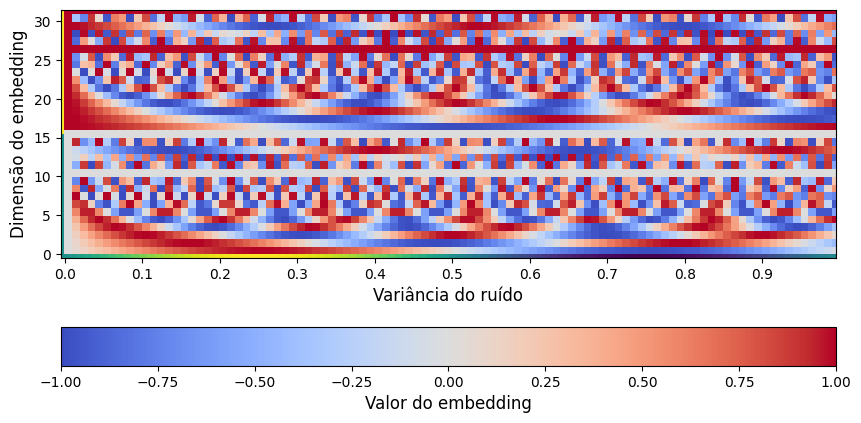

In [77]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))                                             # cria figura
ax.set_xticks(np.arange(0, 100, 10), labels=np.round(np.arange(0.0, 1.0, 0.1), 1))  # ticks a cada 0.1
ax.set_ylabel("Dimensão do embedding", fontsize=12)                                 # rótulo eixo y
ax.set_xlabel("Variância do ruído", fontsize=12)                                    # rótulo eixo x
plt.pcolor(embedding_array, cmap="coolwarm")                                        # mapa de calor
cbar = plt.colorbar(orientation="horizontal")                                       # barra de cores
cbar.set_label("Valor do embedding", fontsize=12)                                   # rótulo da barra
ax.imshow(embedding_array, interpolation="nearest", origin="lower")                 # melhora contraste
plt.show()                                                                          # exibe a figura


## ResidualBlock

In [78]:
class ResidualBlock(nn.Module):
    """Bloco residual 3x3 + 3x3 com BatchNorm (sem affine) e projeção condicional de canais 1x1."""

    def __init__(self, num_channels: int):
        super().__init__()
        self.num_channels = num_channels                                                                # número de canais esperado no bloco
        self.align = nn.LazyConv2d(out_channels=num_channels, kernel_size=1)                            # projeta canais de entrada p/ num_channels quando necessário (1x1) - inicialização preguiçosa de in_channels de acordo com a entrada
        self.path = nn.Sequential(                                                                      # caminho não residual
            nn.BatchNorm2d(num_channels, affine=False),                                                 # BN sem parâmetros de deslocamento e escala: média=0 e var=1
            nn.SiLU(),                                                                                  # não-linearidade suave
            nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1),   # conv 3x3 preserva resolução espacial (H,W)
            nn.Conv2d(in_channels=num_channels, out_channels=num_channels, kernel_size=3, padding=1),   # conv 3x3 preserva resolução espacial (H,W)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Se o número de canais da entrada != self.num_channels, aplica convolução 1x1 p/ alinhar
        in_channels = x.shape[1]                                        # número de canais de entrada
        if in_channels != self.num_channels:                            # verifica canais: (B,C,H,W)
            x = self.align(x)                                           # projeta C_in -> self.num_channels mantendo H,W
        residual = x                                                    # salva a entrada para conexão residual
        y = self.path(x)                                                # BN → SiLU → Conv3x3 → Conv3x3
        return y + residual                                             # soma residual (skip connection)

## DownBlock

In [79]:
class DownBlock(nn.Module):
    """Bloco de downsampling: aplica N blocos residuais e então reduz resolução por 2x via AvgPool2d."""

    def __init__(self, num_channels: int, block_depth: int = 2):
        super().__init__()
        self.blocks = nn.ModuleList([ResidualBlock(num_channels) for _ in range(block_depth)])  # empilha block_depth blocos residuais
        self.pool = nn.AvgPool2d(kernel_size=2)                                          # downsample: reduz (H,W) -> (H/2, W/2)

    def forward(self, x: torch.Tensor, skips: list):
        for blk in self.blocks:
            x = blk(x)                     # aplica bloco residual: shape preservada (B,C,H,W)
            skips.append(x)                # armazena feature map p/ skip connection no caminho de subida (decoder)
        x = self.pool(x)                   # reduz resolução espacial (H,W)->(H/2,W/2), canais mantidos
        return x, skips                    # retorna saída reduzida + lista de skips acumulados


## UpBLock

In [80]:
class UpBlock(nn.Module):
    """Bloco de upsampling: aumenta resolução 2x e consome skips aplicando blocos residuais."""

    def __init__(self, num_channels: int, block_depth: int = 2):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)     # dobra resolução espacial por interpolação bilinear (operação fixa, sem parâmetros treináveis): (H,W) -> (2H,2W)
        self.blocks = nn.ModuleList([ResidualBlock(num_channels) for _ in range(block_depth)]) # empilha block_depth blocos residuais

    def forward(self, x: torch.Tensor, skips: list):
        x = self.up(x)                                                                  # upsample: (B,C,H,W)- > (B,C,2H,2W)
        for blk in self.blocks:
            skip = skips.pop()                                                          # recupera último skip do encoder (ordem LIFO)
            x = torch.cat([x, skip], dim=1)                                             # concatena canais: (B,C_up,H,W)+(B,C_skip,H,W)->(B,C',H,W) ; ResidualBlock alinhará canais se necessário (LazyConv2d)
            x = blk(x)                                                                  # aplica bloco residual após fusão com skip
        return x                                                                        # retorna feature upsampled processada

## U-Net

In [81]:
class UNet(nn.Module):
    def __init__(self, image_size: int, emb_dim: int, sinusoidal_embedding_fn):
        super().__init__()

        # Embedding
        self.image_size = image_size                                                    # guarda H=W da entrada
        self.emb_dim = emb_dim                                                          # dimensão do embedding senoidal
        self.sinusoidal_embedding = sinusoidal_embedding_fn                             # função de embedding temporal
        self.emb_upsample = nn.Upsample(size=(image_size, image_size), mode='nearest')  # upsample fixo (operação determinística, sem pesos)

        # Projeta canais de entrada 3 -> 32 (preserva H,W)
        self.in_proj = nn.Conv2d(in_channels=NUM_CHANNELS, out_channels=32, kernel_size=1)         # 3 -> 32 (preserva H,W)

        # Encoder: 3 níveis (cada DownBlock empilha 'skips' e reduz resolução por 2x); canais: (32) → (64) → (96)
        self.down1 = DownBlock(num_channels=32, block_depth=2)  # nível 1: produz 2 skips @(H,W)     = @64×64
        self.down2 = DownBlock(num_channels=64, block_depth=2)  # nível 2: produz 2 skips @(H/2,W/2) = @32×32
        self.down3 = DownBlock(num_channels=96, block_depth=2)  # nível 3: produz 2 skips @ H/4,W/4) = @16×16

        # Bottleneck: projeta 96 -> 128 e aplica dois blocos residuais
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels=96, out_channels=128, kernel_size=1),     # ajusta canais p/ o gargalo: (B,96,H/8,W/8)->(B,128,H/8,W/8)
            ResidualBlock(num_channels=128),                                             # bloco residual 1 (mantém (B,128,H/8,W/8))
            ResidualBlock(num_channels=128),                                             # bloco residual 2 (mantém (B,128,H/8,W/8))
        )

        # Decoder simétrico: 3 níveis (cada UpBlock faz upsample 2x, consome 2 skips e ajusta canais); canais: 96 → 64 → 32
        self.up3 = UpBlock(num_channels=96, block_depth=2)  # nível 3→2: upsample @(H/8,W/8)->@(H/4,W/4)   = @8×8->@16×16; consome 2 skips; alvo canais=96
        self.up2 = UpBlock(num_channels=64, block_depth=2)  # nível 2→1: upsample @(H/4,W/4)->@(H/2,W/2)   = @16×16->@32×32; consome 2 skips; alvo canais=64
        self.up1 = UpBlock(num_channels=32, block_depth=2)  # nível 1→0: upsample @(H/2,W/2)->@(H,W)       = @32×32->@64×64; consome 2 skips; alvo canais=32

        # Saída: projeta de 32 -> 3
        self.out_conv = nn.Conv2d(in_channels=32, out_channels=NUM_CHANNELS, kernel_size=1)    # (B,32,H,W) -> (B,3,H,W)

        # Inicializa parâmetros da camada de saída com zeros
        nn.init.zeros_(self.out_conv.weight)                                        # pesos zerados
        if self.out_conv.bias is not None:
            nn.init.zeros_(self.out_conv.bias)                                      # viés zerado

    def forward(self, noisy_images: torch.Tensor, noise_variances: torch.Tensor):
        # Entrada da rede
        x = self.in_proj(noisy_images)                              # (B,3,H,W) -> (B,32,H,W)

        # Embedding senoidal do tempo (mesmo t por imagem)
        emb_nhwc = self.sinusoidal_embedding(noise_variances)   # (B,1,1,emb_dim)
        emb = emb_nhwc.permute(0, 3, 1, 2)                      # reorganiza eixos: (B,1,1,emb) -> (B,emb,1,1)
        emb = self.emb_upsample(emb)                            # (B,emb,1,1) -> (B,emb,H,W) upsample fixo por interpolação via 'nearest' (determinístico, sem pesos)

        # Concatena embedding como canais extras antes do primeiro bloco
        # (ResidualBlock interno alinha canais via 1×1 quando necessário)
        x = torch.cat([x, emb], dim=1)                              # concatena em C: (B,32+emb,H,W)

        # Encoder: acumula 'skips' e reduz resolução por 2× a cada nível
        skips = []                                                  # pilha LIFO de mapas para skip-connection
        x, skips = self.down1(x, skips)                             # (B,?,H,W) -> (B,32,H/2,W/2), empilha 2 skips
        x, skips = self.down2(x, skips)                             # (B,64,H/2,W/2) -> (B,64,H/4,W/4), empilha 2 skips
        x, skips = self.down3(x, skips)                             # (B,96,H/4,W/4) -> (B,96,H/8,W/8), empilha 2 skips

        # Bottleneck: aumenta capacidade em canais e refina
        x = self.bottleneck(x)  # aplica projeção 1×1 e os dois blocos residuais em sequência

        # Decoder simétrico: upsample 2x, concat com skip e refina a cada nível
        x = self.up3(x, skips)                                     # consome 2 skips e ajusta para ~96 canais
        x = self.up2(x, skips)                                     # consome 2 skips e ajusta para ~64 canais
        x = self.up1(x, skips)                                     # consome 2 skips e ajusta para ~32 canais

        # Saída final com 3 canais
        return self.out_conv(x)                                     # (B,3,H,W)

## Classe do modelo de difusão

In [82]:
class DiffusionModel(nn.Module):
    def __init__(self, unet: nn.Module, diffusion_schedule=offset_cosine_diffusion_schedule):
        super().__init__()
        self.network = unet                                # rede principal (prediz o ruído ε̂_θ a partir de x_t e t)
        self.ema_network = copy.deepcopy(unet)             # cópia para EMA da U-Net usada apenas em inferência (mais estável)
        self.diffusion_schedule = diffusion_schedule       # cronograma de difusão: retorna (√(1-ᾱ_t), √ᾱ_t) a partir de t ∈ [0,1]

        # buffers não-treináveis para normalização por canal (μ, σ²)
        self.register_buffer("norm_mean", torch.zeros(1, NUM_CHANNELS, 1, 1))  # média por canal (shape: (1,3,1,1))
        self.register_buffer("norm_var",  torch.ones(1, NUM_CHANNELS, 1, 1))   # variância por canal (shape: (1,3,1,1))

        # acumuladores simples para logging da função de perda (média móvel do MAE do ruído)
        self.noise_loss_avg = 0.0                           # média móvel do MAE entre o ruído alvo (ε) e o ruído predito (ε̂_θ)
        self._avg_count = 0                                 # contador de lotes para calcular a média cumulativa da função de perda

        # desativa gradientes na rede EMA (EMA é atualizada por cópia exponencial, não por backprop)
        for p in self.ema_network.parameters():             # percorre todos os parâmetros da EMA
            p.requires_grad = False                         # desliga grad (evita atualizações indevidas)

    #######################################################################
    # métodos utilitários
    #######################################################################

    @torch.no_grad()
    def denormalize(self, images: torch.Tensor):
        """Desfaz normalização por canal: x = μ + σ·x̂ e garante saída em [0,1]."""
        x = self.norm_mean + images * torch.sqrt(self.norm_var)  # reconstrói imagem original: μ + σ·x̂
        return x.clamp(0.0, 1.0)                                 # limita valores para o intervalo [0,1]

    def _update_ema(self, decay: float = EMA):
        """Atualiza a rede EMA: média exponencial dos pesos da rede principal."""
        with torch.no_grad():                                                 # evita gradientes (EMA é manual)
            msd = self.network.state_dict()                                   # pesos atuais da rede treinável
            esd = self.ema_network.state_dict()                               # pesos acumulados na EMA

            for k, v_ema in esd.items():                                      # percorre cada parâmetro da EMA
                # pula parâmetros lazy (LazyConv2d ainda não materializados)
                if isinstance(v_ema, UninitializedParameter):
                    continue
                v_src = msd[k]                                                # valor atual do parâmetro da rede
                # aplica EMA apenas em tensores float (parâmetros treináveis)
                if isinstance(v_ema, torch.Tensor) and v_ema.is_floating_point():
                    v_ema.mul_(decay).add_(v_src, alpha=(1.0 - decay))        # v_ema = decay*v_ema + (1-decay)*v_src
                else:
                    v_ema.copy_(v_src)                                        # buffers não-float são copiados diretamente

    #######################################################################
    # núcleo do modelo de difusão
    #######################################################################

    def denoise(self, noisy_images: torch.Tensor, noise_rates: torch.Tensor, signal_rates: torch.Tensor, training: bool):
        """Prediz o ruído ε̂_θ e reconstrói x̂_0 a partir de x_t e das taxas (√(1−ᾱ_t), √ᾱ_t)."""

        # usa a rede principal no treino e a rede EMA na inferência (mais estável)
        net = self.network if training else self.ema_network

        # prediz o ruído ε̂_θ dado x_t e (1 - ᾱ_t) (passado como embedding de tempo para a U-Net)
        pred_noises = net(noisy_images, noise_rates.pow(2))  # shape: (B,3,H,W) ; passa 1 - ᾱ_t , pois noise_rates = sqrt(1 - ᾱ_t)

        # reconstrói a imagem limpa x̂_0 usando a fórmula inversa:
        # x_t = √ᾱ_t·x_0 + √(1−ᾱ_t)·ε  →  x̂_0 = (x_t − √(1−ᾱ_t)·ε̂) / √ᾱ_t
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates

        return pred_noises, pred_images

    @torch.no_grad()
    def reverse_diffusion(self, initial_noise: torch.Tensor, diffusion_steps: int):
        """Processo reverso DDIM determinístico (η=0): x_T ~ N(0,I) → x̂_0 via passos uniformes em t ∈ [1,0]."""
        # =========================================================
        # 0. CONSTANTES
        # =========================================================
        B = initial_noise.shape[0]                                              # (a) tamanho do lote
        step_size = 1.0 / float(diffusion_steps)                                # (b) tamanho do passo no tempo contínuo Δt = 1/T (T = diffusion_steps)
        current_images = initial_noise                                          # (c) inicializa x_T = ε_T ~ N(0, I)(ruído puro)
        ones = torch.ones((B, 1, 1, 1), device=DEVICE)                          # (d) tensor base p/ construir t (broadcast)

        # =========================================================
        # 1. LOOP DE DENOISE: k = 0,...,T-1 (t: 1.0 → 0.0)
        # =========================================================
        for step in range(diffusion_steps):                                     # k = 0,...,T-1

            # ----------------------------------------------
            # 1.1  Tempo contínuo atual: t_k = 1 − k · Δt
            # ----------------------------------------------
            t = ones - step * step_size      # shape: (B,1,1,1)

            # ----------------------------------------------
            # 1.2  Taxas no tempo atual t_k: √ᾱ_t (sinal) e √(1-ᾱ_t) (ruído)
            # ----------------------------------------------
            noise_rates, signal_rates = self.diffusion_schedule(t)              # noise_rates = √(1-ᾱ_t), signal_rates = √ᾱ_t

            # ----------------------------------------------
            # 1.3  Predição do ruído (ε̂_θ) e reconstrução (x̂_0)
            # ----------------------------------------------
            pred_noises, pred_images = self.denoise(current_images, noise_rates, signal_rates, training=False)  # ε̂_θ(x_t,1-ᾱ_t) e x̂_0 = (x_t - √(1-ᾱ_t)·ε̂)/√ᾱ_t

            # ----------------------------------------------
            # 1.4  Tempo do próximo passo: t_{k+1} = t_k − Δt
            # ----------------------------------------------
            t_next = (t - step_size).clamp_min(0.0)                                # evita valores negativos para garantir faixa válida
            next_noise_rates, next_signal_rates = self.diffusion_schedule(t_next)  # taxas no próximo passo

            # ----------------------------------------------
            # 1.5  Passo DDIM determinístico (η=0): x_{k+1} = √ᾱ_{k+1} · x̂_0  +  √(1-ᾱ_{k+1}) · ε̂_θ
            # ----------------------------------------------
            current_images = next_signal_rates * pred_images + next_noise_rates * pred_noises

        # =========================================================
        # 2. RETORNA A ÚLTIMA ESTIMATIVA x̂_0  (t=0) (imagem “limpa”)
        # =========================================================
        return pred_images                                             # shape = (B,3,H,W)

    @torch.no_grad()
    def generate(self, num_images: int, diffusion_steps: int, initial_noise: torch.Tensor | None = None):
        """Gera amostras novas via processo reverso (DDIM η=0) a partir de ε_T ~ N(0,I)."""
        dtype  = next(self.parameters()).dtype                                                              # garante dtype consistente (fp32/fp16/bf16)

        # cria ruído inicial se não for fornecido: shape (N, C=3, H, W) em canais-primeiro
        if initial_noise is None:
            initial_noise = torch.randn(num_images, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE, dtype=dtype)  # ε_T ~ N(0,I)
        else:
            initial_noise = initial_noise.to(device=DEVICE, dtype=dtype)                                    # ajusta device/dtype do ruído fornecido

        generated_images = self.reverse_diffusion(initial_noise, diffusion_steps)                           # executa DDIM determinístico: x_T → x̂_0
        generated_images = self.denormalize(generated_images)                                               # desfaz normalização: μ + σ·x̂
        return generated_images                                                                             # retorna (N,C,H,W) em [0,1]

    #######################################################################
    # treinamento e avaliação
    #######################################################################

    def train_step(self, images: torch.Tensor, optimizer: torch.optim.Optimizer, loss_fn=nn.L1Loss(reduction="mean")):
        """Um passo de treino: amostra t̂, corrompe x̃, prediz ε̂_θ e atualiza θ + EMA."""
        self.train()                                                      # coloca a U-Net em modo de treinamento
        optimizer.zero_grad()                                             # zera gradientes (evita resíduos de steps anteriores)

        # normaliza entrada por canal: x̃ = (x − μ) / σ  (buffers: norm_mean, norm_var em shape (1,3,1,1))
        x = (images - self.norm_mean) / (torch.sqrt(self.norm_var))

        # amostra ruído e tempos: ε ~ N(0,I), t̂ ~ U(0,1)  (t em shape (B,1,1,1) para broadcast)
        B, _, H, W = x.shape                                             # extrai dimensões do lote
        eps = torch.randn_like(x)                                        # ruído alvo com mesmo shape de x̃: ε ~ N(0,I)
        t = torch.rand(B, 1, 1, 1, device=DEVICE)                        # tempos contínuos uniformes: t̂ ~ U(0,1)

        # obtém taxas do cronograma: signal_rates = √ᾱ_t, noise_rates = √(1−ᾱ_t)
        noise_rates, signal_rates = self.diffusion_schedule(t)           # ambos prontos p/ broadcast (B,1,1,1)

        # difusão direta: x_t = √ᾱ_t·x̃ + √(1−ᾱ_t)·ε
        x_t = signal_rates * x + noise_rates * eps                       # mistura imagem normalizada e ruído

        # rede UNet prediz o ruído ε̂_θ(x_t, t)
        pred_eps, _ = self.denoise(x_t, noise_rates, signal_rates, training=True)  # saída principal é ε̂_θ; x̂_0 é calculado mas não entra na função de perda

        # função de perda MAE = ||ε − ε̂_θ||_1
        loss = loss_fn(pred_eps, eps)                                    # norma L1 da diferença entre o ruído alvo e ruído predito

        # backprop e passo do otimizador (atualiza parâmetros da rede principal)
        loss.backward()                                                  # computa gradientes de θ
        optimizer.step()                                                 # aplica atualização de θ

        # atualiza pesos da rede EMA: θ_EMA ← decay·θ_EMA + (1−decay)·θ
        self._update_ema(decay=EMA)                                      # suaviza parâmetros para inferência estável

        # logging simples: média cumulativa do MAE do ruído ao longo dos lotes
        self._avg_count += 1                                                            # incrementa contador de lotes vistos
        self.noise_loss_avg += (loss.item() - self.noise_loss_avg) / self._avg_count    # média cumulativa incremental

        return loss.item()                                               # retorna escalar do loss (para exibir no tqdm)


    @torch.no_grad()
    def eval_step(self, images: torch.Tensor, loss_fn=nn.L1Loss(reduction="mean")):
        """Um passo de avaliação/validação (usa EMA)."""
        self.eval()                                                   # modo eval
        # normaliza como no treino
        x = (images - self.norm_mean) / (torch.sqrt(self.norm_var) + 1e-8)

        B, _, H, W = x.shape
        eps = torch.randn_like(x)                                     # ruído
        t = torch.rand(B, 1, 1, 1, device=x.device)                   # tempos

        noise_rates, signal_rates = self.diffusion_schedule(t)        # taxas
        x_t = signal_rates * x + noise_rates * eps                    # x_t

        # usa EMA para inferência estável
        pred_eps, _ = self.denoise(x_t, noise_rates, signal_rates, training=False)

        loss = loss_fn(pred_eps, eps)                                 # MAE
        return loss.item()                                            # escalar


    def forward(self, noisy_images: torch.Tensor, noise_variances: torch.Tensor, use_ema: bool = False):
        """Encaminha entradas para a U-Net (ou EMA) — necessário p/ torchinfo.summary."""
        net = self.ema_network if use_ema else self.network  # escolhe rede (EMA ou principal)
        return net(noisy_images, noise_variances)             # retorna saída da U-Net

In [83]:
# Instancia o modelo de difusão completo (U-Net + EMA + normalizador)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = UNet(
    image_size=IMAGE_SIZE,
    emb_dim=NOISE_EMBEDDING_SIZE,
    sinusoidal_embedding_fn=sinusoidal_embedding,  # <<<<< aqui!
).to(device)

ddm = DiffusionModel(unet).to(device)

In [84]:
def materialize_all_lazy_in_unet(unet: nn.Module, image_size: int, device=None):
    """Força a materialização de todos os LazyConv2d usados como 'align' nos ResidualBlocks."""
    if device is None:
        device = next(unet.parameters()).device
    with torch.no_grad():
        for m in unet.modules():
            # Procura especificamente pelos seus ResidualBlock que possuem o atributo 'align'
            if hasattr(m, "align") and isinstance(m.align, nn.LazyConv2d):
                # Cria um dummy com C_in != width para garantir a materialização
                C_in = m.num_channels + 1  # qualquer valor != m.width
                dummy = torch.zeros(1, C_in, 1, 1, device=device)  # 1x1 já é suficiente p/ Conv1x1
                _ = m.align(dummy)  # chama o módulo para fixar pesos/ses de LazyConv2d

In [85]:
ddm.to(device).eval()
with torch.no_grad():
    dummy_x = torch.zeros(1, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
    dummy_t = torch.zeros(1, 1, 1, 1, device=device)

    # 1) materializa alguns LZ durante um forward completo
    _ = ddm.network(dummy_x, dummy_t)

    # 2) força materialização de TODOS os LazyConv2d remanescentes (casos C_in == width)
    materialize_all_lazy_in_unet(ddm.network, IMAGE_SIZE, device)

    # 3) sincroniza e materializa a EMA da mesma forma
    ddm.ema_network.load_state_dict(ddm.network.state_dict(), strict=True)
    _ = ddm.ema_network(dummy_x, dummy_t)  # passa uma vez
    materialize_all_lazy_in_unet(ddm.ema_network, IMAGE_SIZE, device)

    # 4) congela EMA
    for p in ddm.ema_network.parameters():
        p.requires_grad = False


In [86]:
from torchinfo import summary

# Resumo só da U-Net (ddm.network)
summary(
    ddm.network,
    input_data=(dummy_x, dummy_t),
    col_names=("kernel_size", "output_size", "num_params", "mult_adds"),
    depth=4
)

Layer (type:depth-idx)                        Kernel Shape              Output Shape              Param #                   Mult-Adds
UNet                                          --                        [1, 1, 32, 32]            --                        --
├─Conv2d: 1-1                                 [1, 1]                    [1, 32, 32, 32]           64                        65,536
├─Upsample: 1-2                               --                        [1, 32, 32, 32]           --                        --
├─DownBlock: 1-3                              --                        [1, 32, 16, 16]           --                        --
│    └─ModuleList: 2-1                        --                        --                        --                        --
│    │    └─ResidualBlock: 3-1                --                        [1, 32, 32, 32]           --                        --
│    │    │    └─Conv2d: 4-1                  [1, 1]                    [1, 32, 32, 32]           2,

In [87]:
# Resumo do wrapper DiffusionModel (encaminha para a U-Net no forward)
# Se quiser forçar o uso da EMA aqui, passe kwargs={"use_ema": True}
summary(
    ddm,
    input_data=(dummy_x, dummy_t),
    col_names=("kernel_size", "output_size", "num_params", "mult_adds"),
    depth=3,
    # kwargs={"use_ema": False}  # opcional; default já é False
)

Layer (type:depth-idx)                             Kernel Shape              Output Shape              Param #                   Mult-Adds
DiffusionModel                                     --                        [1, 1, 32, 32]            1,758,881                 --
├─UNet: 1-1                                        --                        [1, 1, 32, 32]            --                        --
│    └─Conv2d: 2-1                                 [1, 1]                    [1, 32, 32, 32]           64                        65,536
│    └─Upsample: 2-2                               --                        [1, 32, 32, 32]           --                        --
│    └─DownBlock: 2-3                              --                        [1, 32, 16, 16]           --                        --
│    │    └─ModuleList: 3-1                        --                        --                        40,160                    --
│    │    └─AvgPool2d: 3-2                         2             

In [88]:
@torch.no_grad()
def compute_dataset_mean_var(dataloader, device):
    count = torch.zeros(NUM_CHANNELS, device=device)
    mean  = torch.zeros(NUM_CHANNELS, device=device)
    M2    = torch.zeros(NUM_CHANNELS, device=device)  # soma dos quadrados das diferenças (para var)

    for batch, _ in dataloader:
        x = batch.to(device)  # (B,3,H,W) em [0,1]
        B, C, H, W = x.shape
        n = torch.tensor(B*H*W, device=device, dtype=torch.float32)

        # média por canal do batch e soma de quadrados por canal do batch
        xb = x.per_channel() if hasattr(x, "per_channel") else x  # só pra clareza
        batch_mean = x.mean(dim=[0,2,3])                  # (3,)
        # variância *amostral* do batch em termos de soma de quadrados:
        # soma dos quadrados em relação à própria média do batch
        batch_var  = x.var(dim=[0,2,3], unbiased=False)   # (3,)
        batch_M2   = batch_var * n                        # M2 do batch

        # merge “online” (canal a canal)
        delta = batch_mean - mean
        total = count + n

        # atualiza mean
        mean += delta * (n / total)

        # atualiza M2 = M2_a + M2_b + delta^2 * n_a * n_b / total
        M2 += batch_M2 + (delta**2) * (count * n / total)

        # atualiza contagem
        count = total

    var = M2 / count.clamp_min(1.0)  # variância populacional por canal
    mean = mean.view(1,NUM_CHANNELS,1,1)
    var  = var.view(1,NUM_CHANNELS,1,1)
    return mean, var


# Treinamento

In [89]:
class DiffusionSamplerCallback:
    def __init__(self, model, num_img, plot_steps, output_dir="./output"):
        self.model = model                                               # modelo de difusão
        self.num_img = num_img                                           # número de imagens a gerar por época
        self.plot_steps = plot_steps                                     # número de passos de difusão reversa (amostragem)
        self.output_dir = output_dir                                     # diretório para salvar imagens geradas

        # Ruído fixo: permite observar evolução das mesmas amostras ao longo das épocas
        self.image_size = model.network.image_size
        self.fixed_noise = torch.randn(
            num_img, NUM_CHANNELS, self.image_size, self.image_size, device=DEVICE            # (N,C,H,W) ~ N(0,1)
        )

    def on_epoch_end(self, epoch):
        os.makedirs(self.output_dir, exist_ok=True)                      # cria diretório se não existir
        self.model.eval()                                                # modo avaliação
        with torch.no_grad():                                            # desabilita gradientes (gera mais rápido / utiliza menos memória)
            imgs = self.model.generate(                                  # gera amostras a partir de ruído ~ N(0,1)
                num_images=self.num_img,                                 # quantidade de imagens
                diffusion_steps=self.plot_steps,                         # número de passos
                initial_noise=self.fixed_noise                           # ruído fixo p/ observar evolução
            )                                                            # saída: (B,C,H,W) em [0,1]
            imgs = (
                imgs.permute(0, 2, 3, 1)                                 # reorganiza eixos: (N,C,H,W) -> (N,H,W,C)
                    .cpu()                                               # move tensor para CPU
                    .numpy()                                             # converte para NumPy para plotar/salvar
            )
        save_path = f"{self.output_dir}/generated_img_{epoch:03d}.png"   # caminho do arquivo
        plot_images(imgs, save_to=save_path, show=False, ylabel= f"Época {epoch}")                 # mostra grid e salva PNG (função plot_images espera (N,H,W,C))

    def save_timelapse_gif(self, gif_path="timelapse.gif", fps=2):
        """Constroi um GIF a partir das imagens geradas no output_dir, sem bordas."""
        frames = []
        img_files = sorted(
            f for f in os.listdir(self.output_dir)
            if f.startswith("generated_img_") and f.endswith(".png")
        )

        for fname in img_files:
            img = plt.imread(os.path.join(self.output_dir, fname))          # lê PNG (H,W,C) em uint8/float
            h, w = img.shape[:2]                                            # dimensões da imagem

            # Cria figura do tamanho exato da imagem em pixels (sem bordas)
            dpi = 100                                                       # DPI de referência
            fig = plt.figure(frameon=False, figsize=(w / dpi, h / dpi), dpi=dpi)  # 1 px = 1 px
            ax = plt.Axes(fig, [0, 0, 1, 1])                                # eixos ocupam 100% da figura
            fig.add_axes(ax)                                                # adiciona eixos
            ax.axis("off")                                                  # remove eixos
            ax.imshow(img, interpolation="nearest")                         # renderiza sem suavização

            # Converte canvas em array (RGBA) e descarta alfa
            fig.canvas.draw()                                               # força render
            buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)   # buffer RGBA contíguo
            frame = buf.reshape(h, w, 4)[..., :3]                            # reshape correto + remove alfa

            frames.append(frame)                                            # acumula frame
            plt.close(fig)                                                  # fecha figura para liberar memória

        imageio.mimsave(gif_path, frames, fps=fps)                          # salva GIF
        print(f"GIF salvo em {gif_path}.")

In [90]:
optimizer = torch.optim.AdamW(                       # otimizador AdamW (Adam + decaimento L2 desacoplado)
    ddm.network.parameters(),                        # parâmetros treináveis da U-Net (modelo principal, não EMA)
    lr=LEARNING_RATE,                                # taxa de aprendizado
    weight_decay=WEIGHT_DECAY                        # regularização L2
)
criterion = nn.L1Loss(reduction="mean")              # função de perda MAE (Mean Absolute Error): média ||ε - ε̂_θ||_1 no lote

In [91]:
torch.manual_seed(0)                             # fixa a semente p/ reprodutibilidade

In [92]:
sampler_cb = DiffusionSamplerCallback(           # callback para gerar imagens ao final de cada época
    model=ddm,
    num_img=10,                                  # gera 10 amostras por época
    plot_steps=PLOT_DIFFUSION_STEPS,             # número de passos na amostragem
    output_dir="./output"                        # diretório onde as amostras serão salvas
)

Epoch 1/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/937 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/937 [00:00<?, ?it/s]

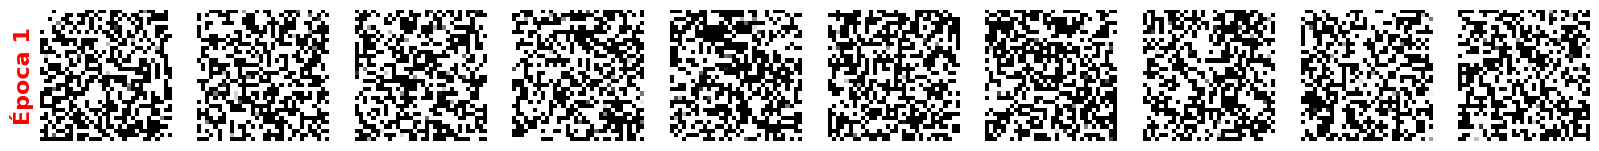

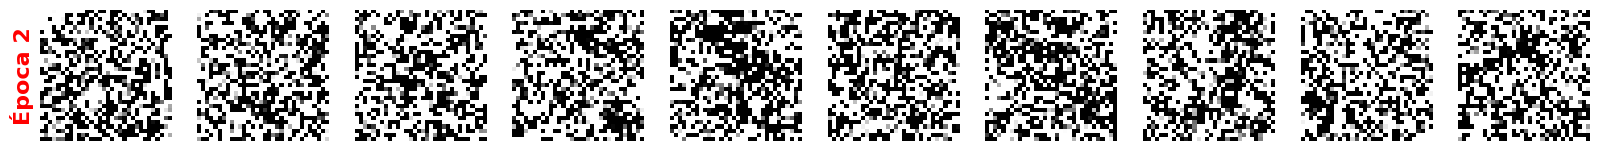

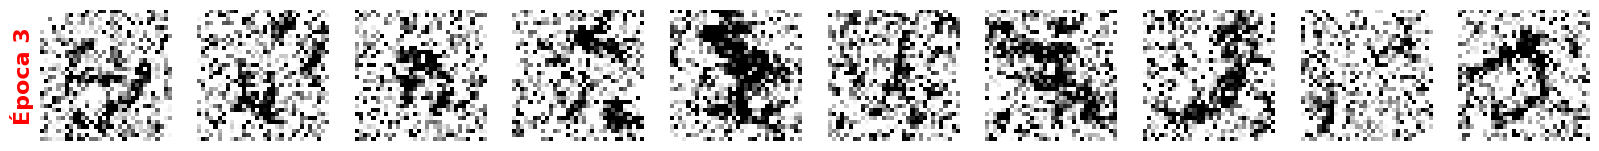

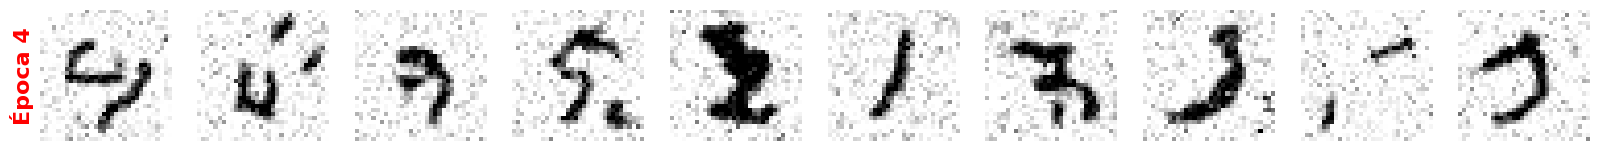

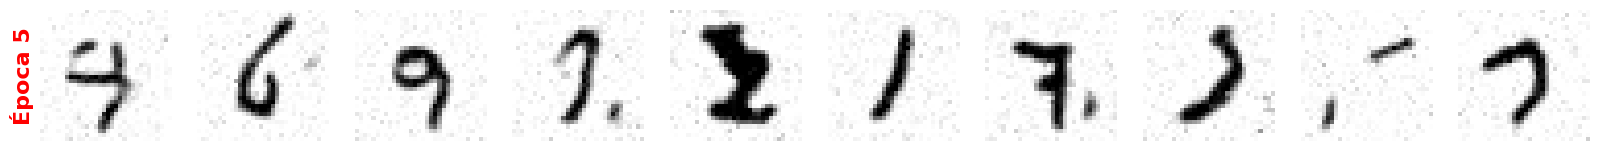

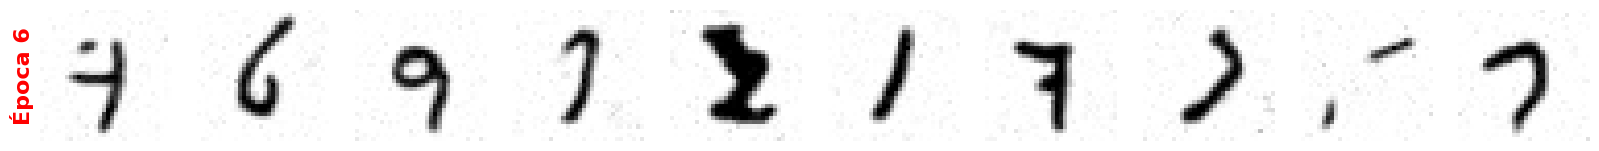

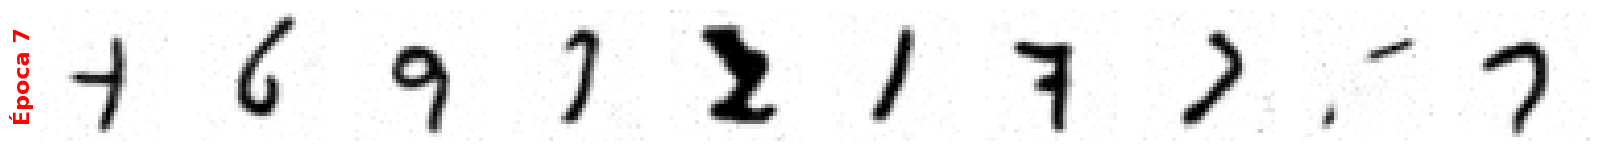

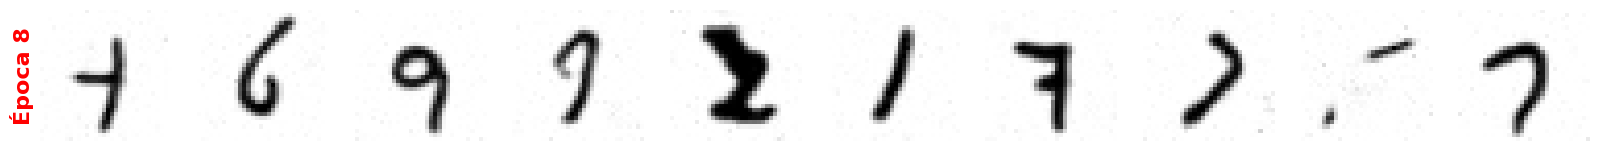

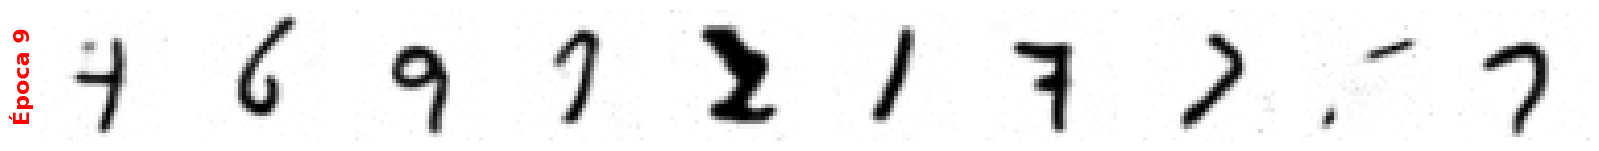

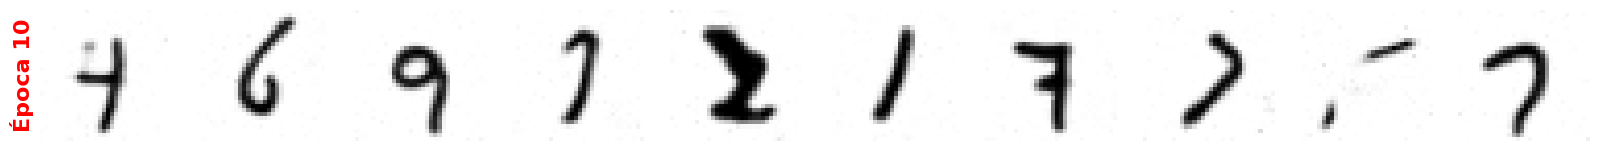

In [93]:
for epoch in range(1, EPOCHS + 1):               # loop de épocas

    ddm.train()                                  # garante modo  de treinamento (caso callback tenha mudado p/ eval)
    running = 0.0                                # soma acumulada da função de perda (p/ média)
    n = 0                                        # contador de lotes

    pbar = tqdm(train_dl,                        # inicializa barra de progresso
                desc=f"Epoch {epoch}/{EPOCHS}")  # texto exibido

    for imgs, _ in pbar:                         # itera minibatches
        imgs = imgs.to(DEVICE)                   # move imagens p/ GPU

        loss = ddm.train_step(                   # passo de treinamento: ruído-alvo vs ruído predito
            imgs,
            optimizer,
            loss_fn=criterion                    # MAE para ruído (ε~N(0,1))
        )

        running += loss                          # acumula função de perda
        n += 1                                   # incrementa contador
        avg_loss = running / n                   # média da função de perda na época

        pbar.set_postfix(MAE=f"{avg_loss:.4f}") # imprime função de perda atualizada na barra

    sampler_cb.on_epoch_end(epoch)               # gera e salva imagens da difusão

In [94]:
gif_path = "./output/training_timelapse.gif"                # caminho do arquivo GIF
sampler_cb.save_timelapse_gif(
    gif_path=gif_path,                                      # onde salvar o GIF
    fps=2                                                   # frames por segundo (velocidade da animação)
)

GIF salvo em ./output/training_timelapse.gif.


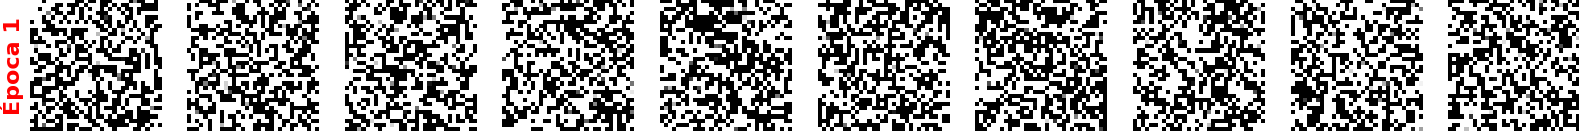

In [95]:
display(Image(filename=gif_path))                           # exibe o GIF diretamente no notebook

# Amostragem

## Geração de novas imagens de flores

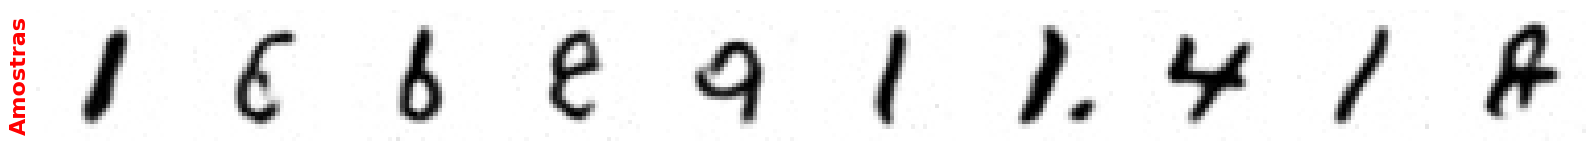

In [96]:
ddm.eval()                                      # ativa modo de avaliação
with torch.no_grad():                           # desabilita cálculo de gradiente (mais rápido, menos memória)
    imgs = ddm.generate(                        # gera amostras usando o processo de difusão reversa
        num_images=10,                          # número de imagens desejadas
        diffusion_steps=20                      # passos de denoising (menor = mais rápido, maior = mais qualidade)
    )                                           # saída: tensor (N,C,H,W) com valores em [0,1]
    imgs = (
        imgs.permute(0, 2, 3, 1)                # reorganiza eixos: PyTorch (N, C, H, W) -> Matplotlib/NumPy (N, H, W, C)
                 .cpu()                         # move para CPU (caso esteja na GPU)
                 .numpy()                       # converte tensor PyTorch para array NumPy (necessário para plot)
    )
plot_images(imgs, show=True, ylabel="Amostras") # exibe imagens (espera formato (N, H, W, C))

## Avaliar como o **número** de passos de difusão (T) afeta a qualidade da imagem

In [97]:
torch.manual_seed(42)                                               # fixa semente (reprodutibilidade)

In [98]:
# Ruído fixo: permite observar evolução das mesmas amostras com números diferentes de passos de difusão
image_size = ddm.network.image_size                                 # recupera resolução usada pelo U-Net
num_images = 10                                                     # número de amostras a gerar p/ cada T
fixed_noise = torch.randn(
    num_images, NUM_CHANNELS, image_size, image_size, device=DEVICE            # (N,C,H,W) ~ N(0,1)
)

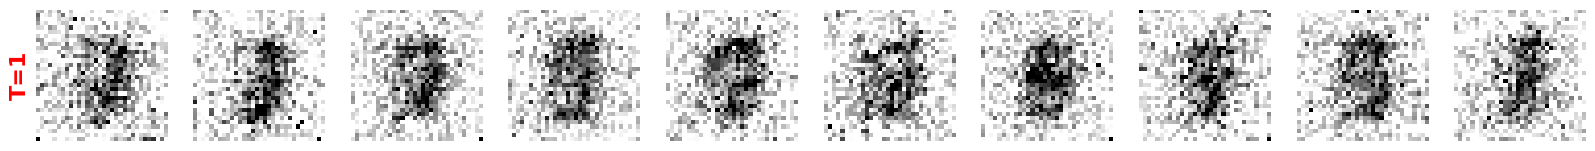

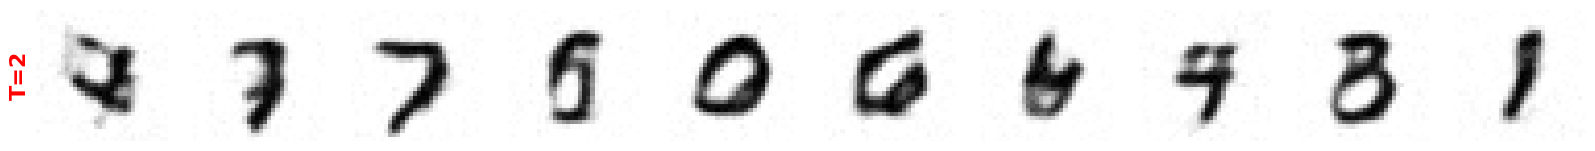

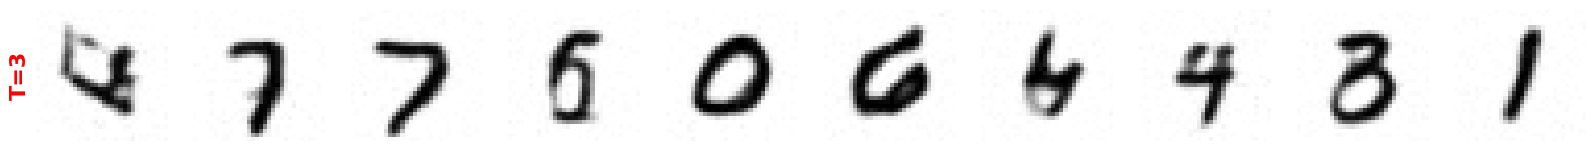

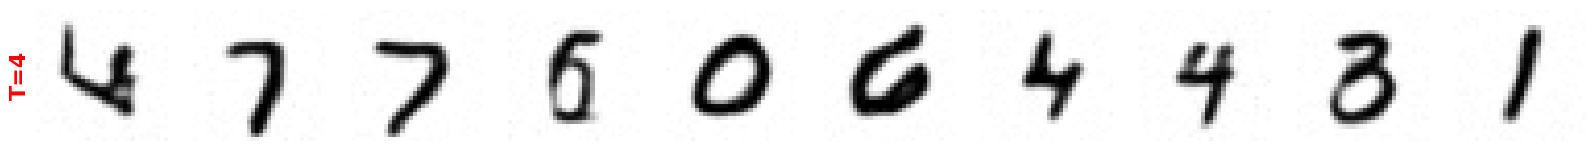

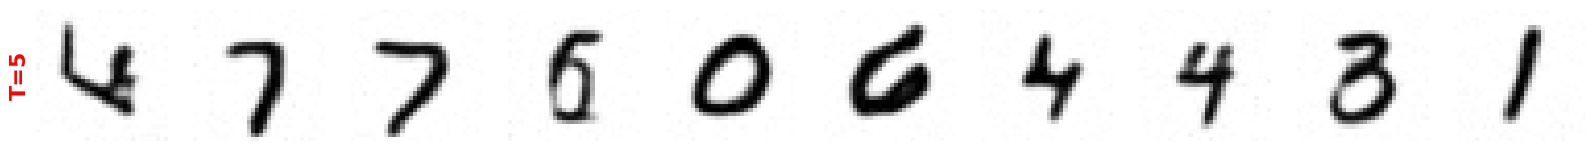

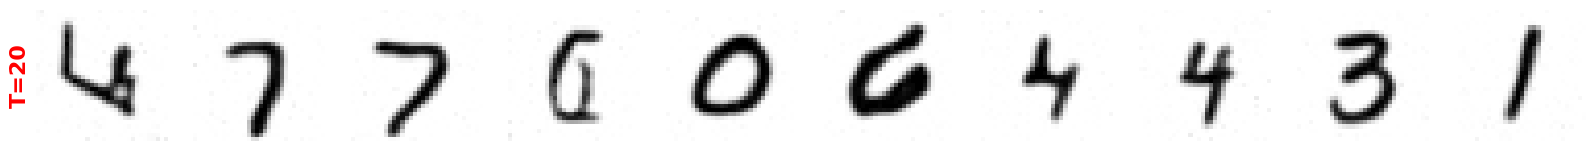

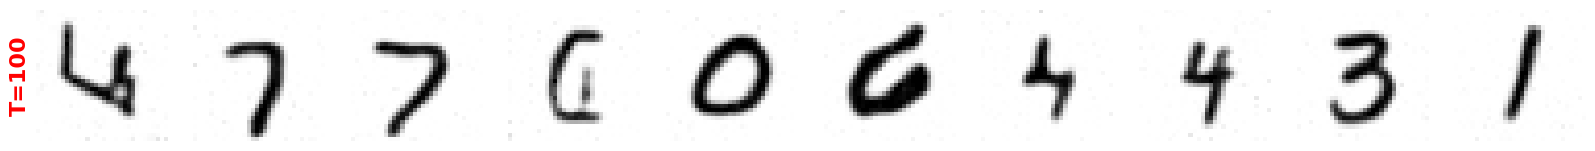

In [99]:
# valores de T (número de passos) para testar: [1,2,3,4,5,20,100]
for diffusion_steps in list(range(1, 6)) + [20] + [100]:
    ddm.eval()                                                      # modo avaliação
    with torch.no_grad():                                           # desativa gradientes
        imgs = ddm.generate(                                        # gera amostras a partir de ruído ~ N(0,1)
            num_images=num_images,                                  # número de imagens a gerar
            diffusion_steps=int(diffusion_steps),                   # T atual (passos do processo reverso)
            initial_noise= fixed_noise
        )                                                           # saída: (B,C,H,W) com valores em [0,1]
        imgs = (imgs.permute(0, 2, 3, 1)                            # reorganiza eixos: (B,C,H,W) -> (B,H,W,C)
                     .cpu()                                         # move p/ CPU
                     .numpy()                                       # converte p/ NumPy p/ visualização
        )
    plot_images(imgs, ylabel=f"T={diffusion_steps}")                # plota grid de 10 imagens
    # colunas: 10 vetores ε₀,…,ε₉ ~ N(0, I)
    # linhas : T = 1,2,3,4,5,20,100

## Interpolação esférica entre dois pontos no espaço latente do ruído

In [100]:
torch.manual_seed(42)                                               # fixa semente (reprodutibilidade)

In [101]:
def spherical_interpolation(a, b, t):
    """
    Dados dois vetores de ruído 'a' e 'b' retorna o ponto intermediário segundo a regra:

    sin(πt/2) · a  +  cos(πt/2) · b

    - Para t = 0   →  b     (cos π·0/2 = 1 , sin = 0)
    - Para t = 1   →  a     (cos = 0, sin π/2 = 1)
    """
    return torch.sin(t * math.pi / 2) * a + torch.cos(t * math.pi / 2) * b

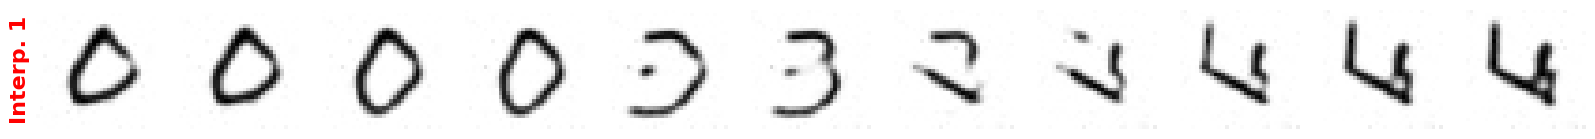

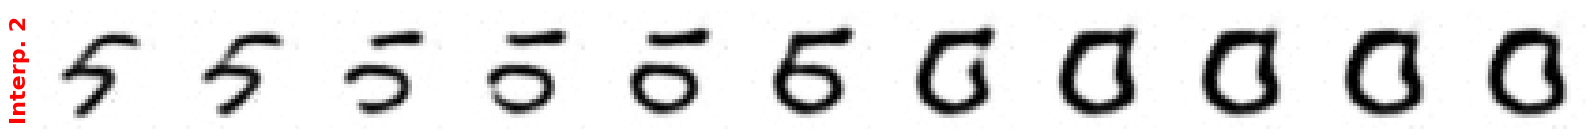

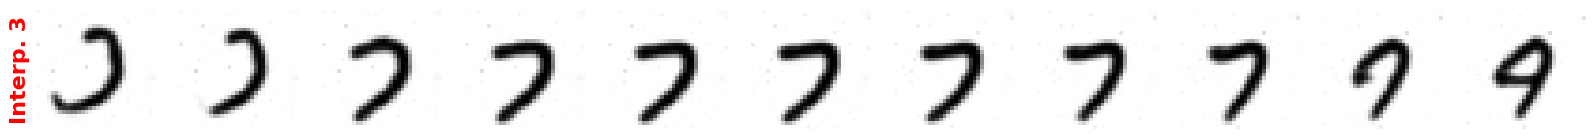

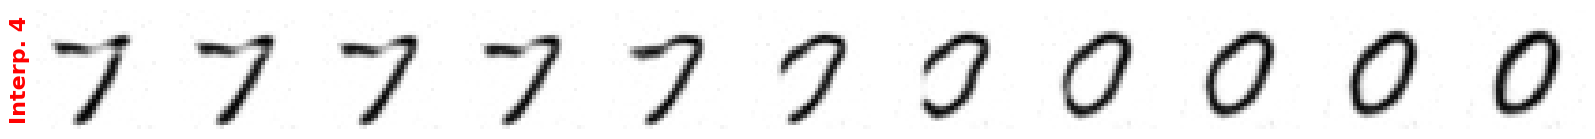

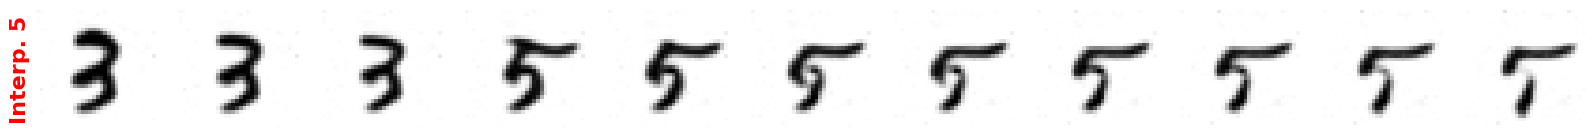

In [102]:
steps = 11
for i in range(5):  # Repete o experimento 5x para ver variedade.
    # -------------------------------------------------------
    # 2.1  Dois pontos aleatórios de ruído (mesma dimensão que as imagens geradas)
    # -------------------------------------------------------
    a = torch.randn(IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS, device=device)  # ruído A (H,W,C): ε₁ ~ N(0, I)
    b = torch.randn(IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS, device=device)  # ruído B (H,W,C): ε₂ ~ N(0, I)

    # -------------------------------------------------------
    # 2.2  Gera uma sequência de ruídos intermediários t = 0.0, 0.1, 0.2, …, 1.0  e interpola
    # -------------------------------------------------------
    t_grid = torch.linspace(0.0, 1.0, steps=steps, device=DEVICE).view(-1, 1, 1, 1)     # shape (steps,1,1,1): 0.0 → 1.0 inclusive
    initial_noise = spherical_interpolation(a.unsqueeze(0), b.unsqueeze(0), t_grid)     # shape (steps,H,W,C)
    initial_noise = initial_noise.permute(0, 3, 1, 2)                                   # NHWC → NCHW para a U-Net: (steps,C,H,W)

    # -------------------------------------------------------
    # 2.3  Reverte o processo de difusão a partir de cada ponto de ruído para obter imagens “entre” a e b
    # -------------------------------------------------------
    ddm.eval()                                                            # modo avaliação
    with torch.no_grad():                                                 # desativa autograd (mais rápido/leve)
        generated = ddm.generate(                                         # gera x̂_0 para cada ruído da sequência
            num_images=initial_noise.shape[0],                            # "steps" imagens
            diffusion_steps=20,                                           # número de passos de amostragem
            initial_noise=initial_noise                                   # ruído inicial fixado (steps,C,H,W)
        )
        imgs = generated.permute(0, 2, 3, 1).cpu().numpy()                # NCHW → NHWC p/ matplotlib


    # -------------------------------------------------------
    # 2.4  Exibe as "steps" imagens: coluna-0 = b, coluna-10 = a. Colunas intermediárias mostram a transição suave de b → a .
    # -------------------------------------------------------
    plot_images(imgs, n=11, ylabel=f"Interp. {i+1}")

# Tarefa:

1. Treine um modelo de difusão com um outro conjunto de dados MNIST (`from torchvision.datasets import MNIST`). Faça as seguintes alterações nos hiperparâmetros:

``` python
IMAGE_SIZE = 32                 # tamanho das imagens (32x32)
NUM_CHANNELS = 1                # número de canais da imagem
```

Faça as alterações necessárias no código para carregar a base de dados MNIST. Diferentemente do que foi feito com o conjunto Oxford flowers, não utilize repetições dos dados.

2. Observe e reporte como o número de passos T afeta a geração de novas imagens.
3. Interpole entre duas imagens no espaço latente e reporte os resultados. Repita o procedimento para 4 pares de imagens.